# Gain Calibration Relative to Node7-Bogota

This notebook estimates one transfer function per node so each node reproduces the same spectral response as `Node7-Bogota`.
The calibration is performed in the PSD domain (dB), frequency bin by frequency bin.


## 1. Analytical Problem Formulation

For each node $i$, and each acquisition row $r$, let:

- $P_{i,r}(f)$: node PSD in dB at frequency $f$.
- $P_{\mathrm{ref},r}(f)$: reference PSD (`Node7-Bogota`) in dB at frequency $f$.

We seek a node-dependent transfer curve $H_i(f)$ such that calibrated spectra satisfy:

$$
P^{\mathrm{cal}}_{i,r}(f) = P_{i,r}(f) + H_i(f) \approx P_{\mathrm{ref},r}(f).
$$

Because values are in dB, applying $H_i(f)$ is additive.


## 2. Transfer Function Estimation

For each synchronized row $r$, the instantaneous required correction is:

$$
\Delta_{i,r}(f) = P_{\mathrm{ref},r}(f) - P_{i,r}(f).
$$

The fitted transfer is the robust central tendency across rows:

$$
H_i(f) = \operatorname{median}_r\, \Delta_{i,r}(f).
$$

A moving-average smoother over frequency is applied to reduce narrow random artifacts and keep a physically plausible gain curve.

Interpretation in linear power units: if $G_i(f)$ is multiplicative gain, then

$$
G_i(f) = 10^{H_i(f)/10}.
$$


## 3. Frequency Alignment and Interpolation

Each node can have a different sweep range, so spectra are interpolated onto the reference frequency axis before computing $\Delta_{i,r}(f)$.

Only overlapping frequency support contributes to the fit.
If there is no overlap, $H_i(f)$ is undefined relative to Node7 and the node is skipped.
This is why `Node9-Funza` is excluded (its band is 137-157 MHz, while Node7 uses 88-108 MHz).


## 4. Fit Quality Metric

In the ROI $[97, 99]$ MHz, the notebook reports median absolute error (MAE) before and after calibration:

$$
\mathrm{MAE}_{\mathrm{before}} = \operatorname{median}_{r, f \in \mathrm{ROI}} \left| P_{\mathrm{ref},r}(f) - P_{i,r}(f) \right|.
$$

$$
\mathrm{MAE}_{\mathrm{after}} = \operatorname{median}_{r, f \in \mathrm{ROI}} \left| P_{\mathrm{ref},r}(f) - \big(P_{i,r}(f) + H_i(f)\big) \right|.
$$

Improvement is $\mathrm{MAE}_{\mathrm{before}} - \mathrm{MAE}_{\mathrm{after}}$. Positive values indicate successful calibration.


## 5. Visual Validation

The notebook reproduces the `PSD vs Frequency` style from `DatasetFM-v2.ipynb` with two panels:

- Top panel: raw PSD curves for one selected row.
- Bottom panel: calibrated PSD curves after applying each $H_i(f)$, compared to Node7.

A good calibration is observed when the calibrated curves collapse toward the reference trace over the analysis band.


Loaded 10 node tables from 'DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv'

Transfer model in dB:
PSD_node_calibrated(f) = PSD_node(f) + H_node(f)
H_node(f) = median_rows(PSD_ref(f) - PSD_node(f))

Fit summary (ROI MAE in dB):
         node    status                              reason  rows_available  rows_used  mae_before_db  mae_after_db  mae_improvement_db
 Node1-Bogota    fitted                                  ok             105        105       0.845609      0.448807            0.396802
Node10-Bogota    fitted                                  ok             104        104       0.872851      0.517174            0.355678
 Node2-Bogota    fitted                                  ok             105        105       0.836864      0.452844            0.384020
 Node3-Bogota    fitted                                  ok             105        105       2.377780      0.532067            1.845712
 Node4-Bogota    fitted                                  ok             105        105  

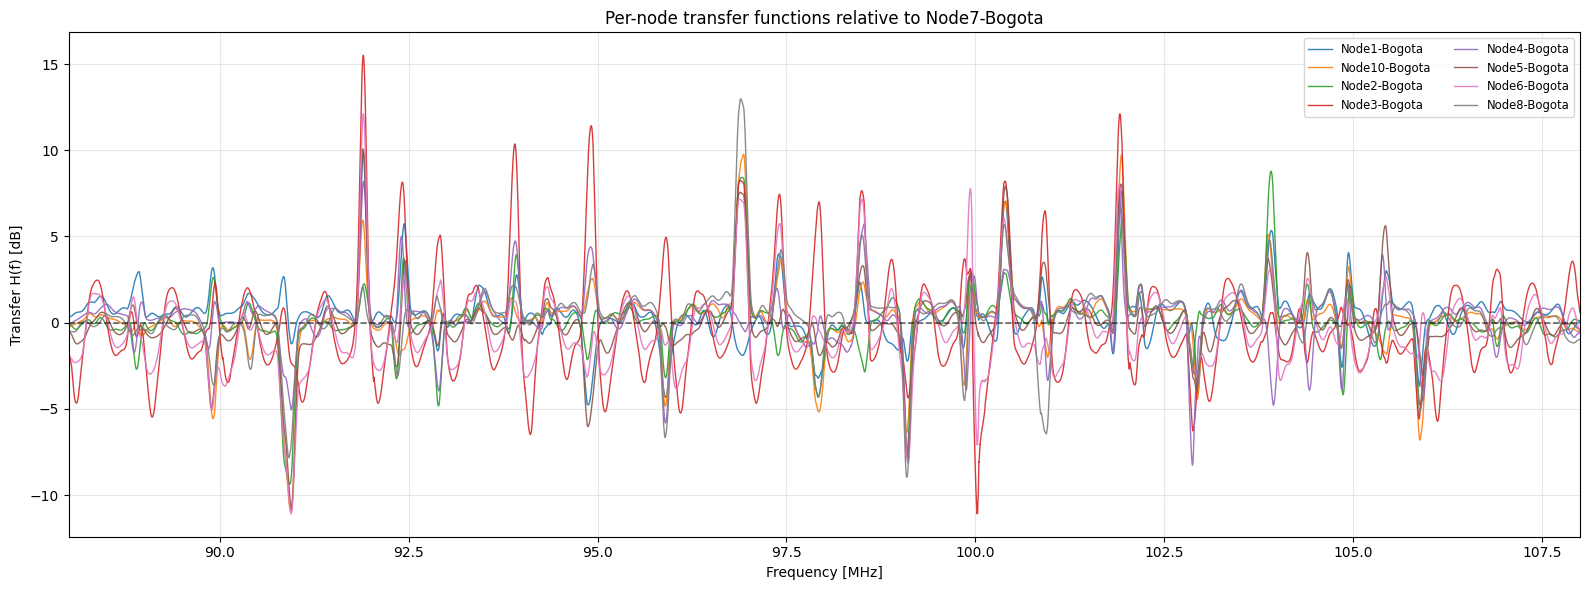

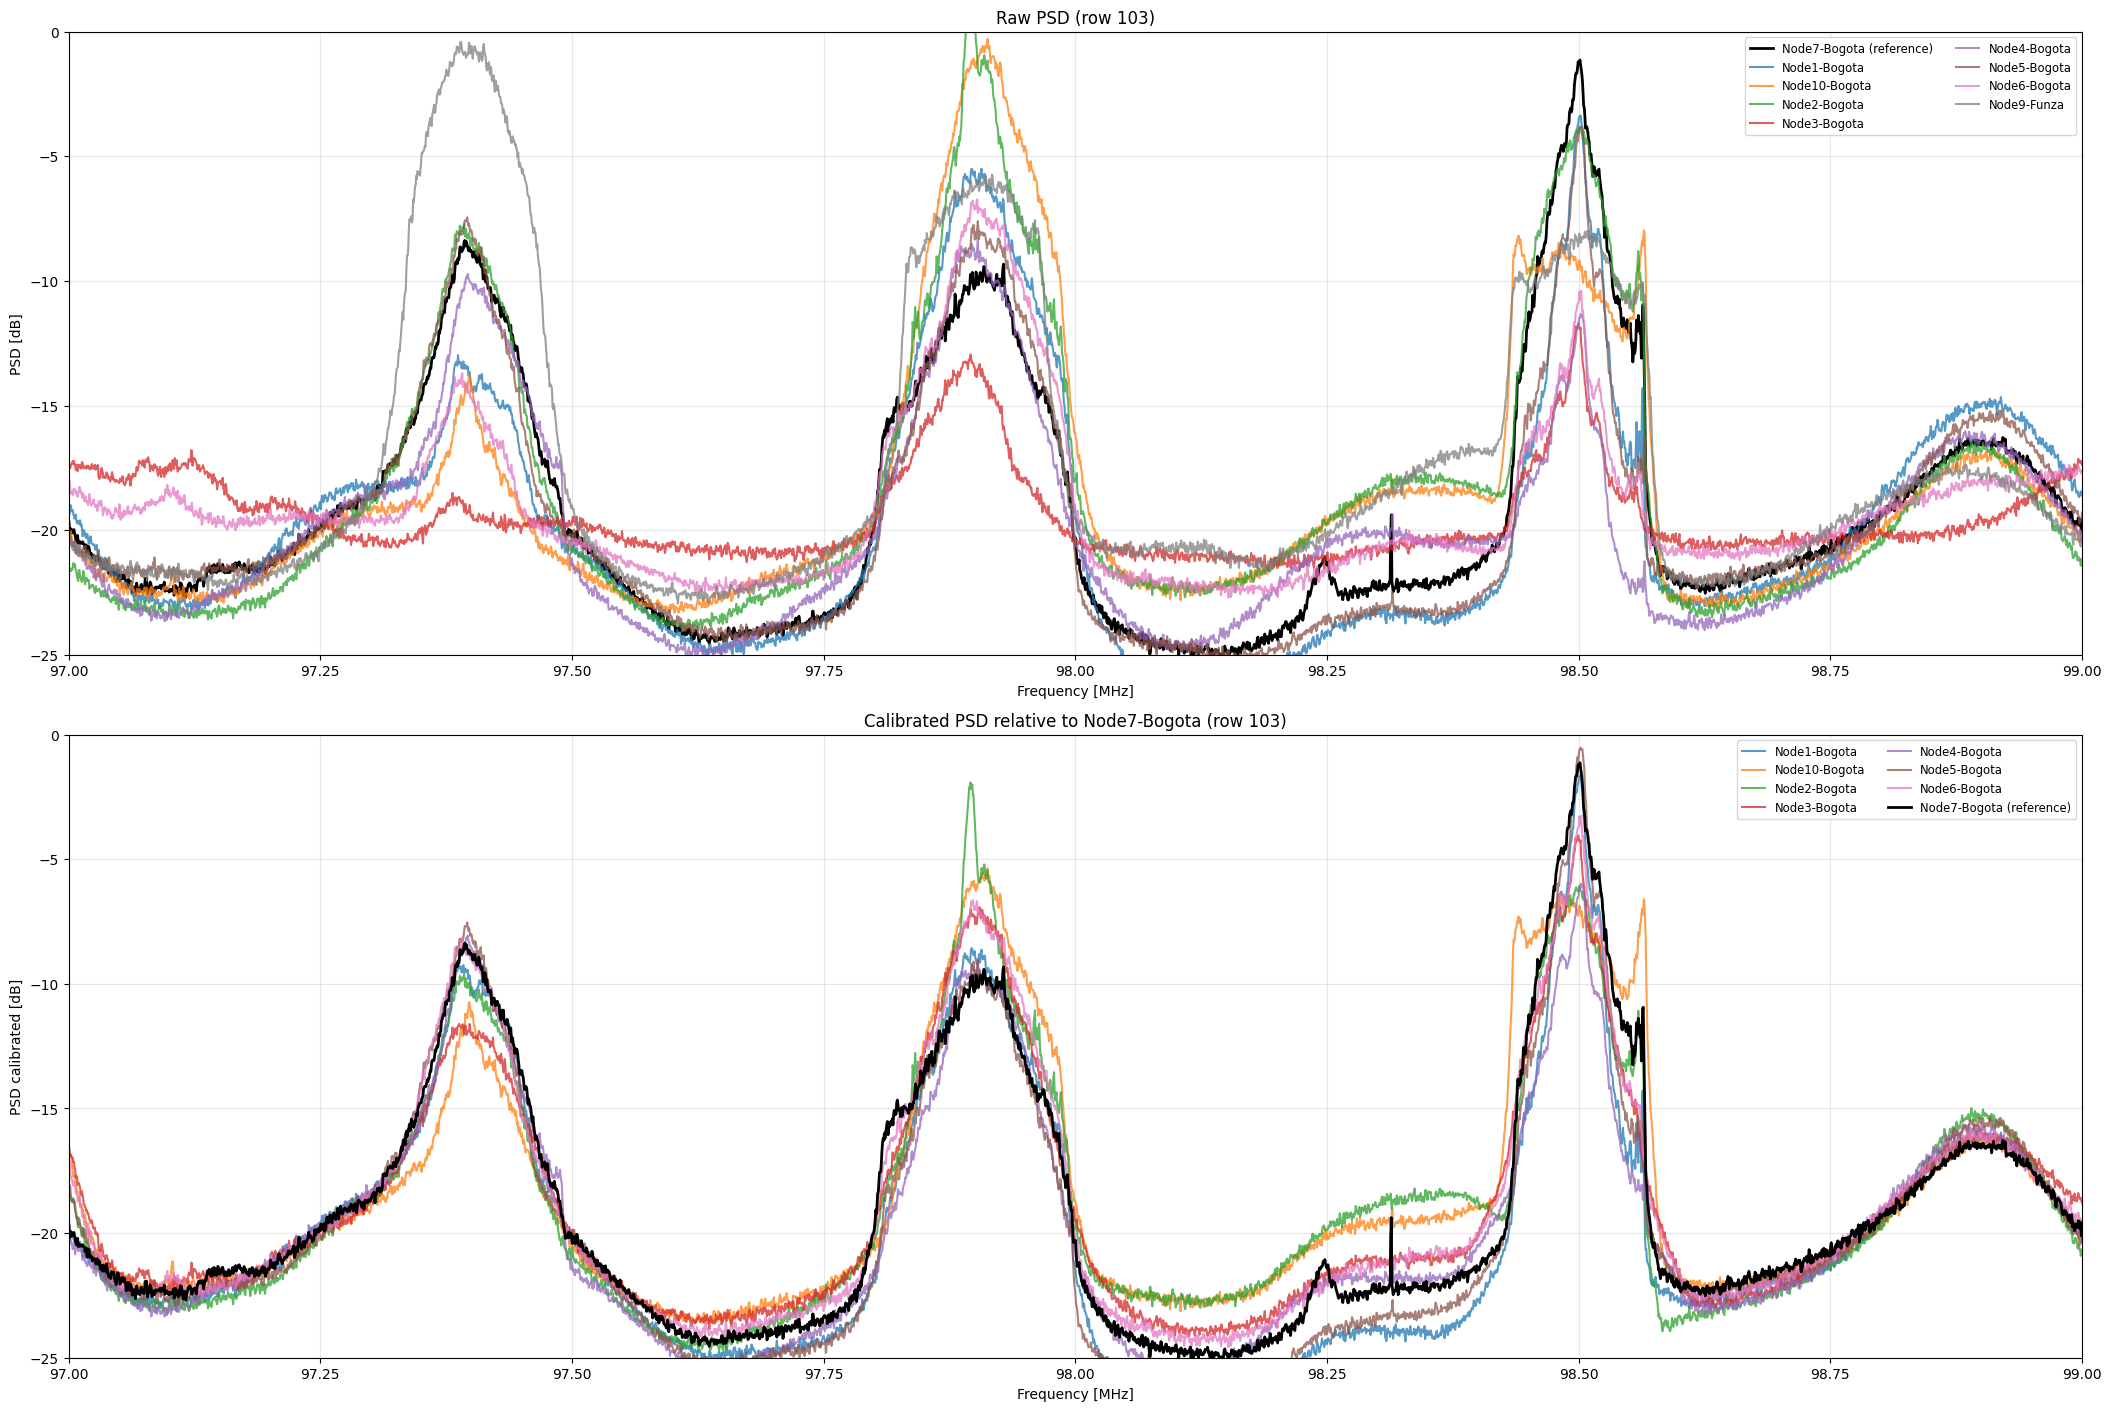

In [3]:
from __future__ import annotations

import ast
import glob
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# -----------------------
# Configuration
# -----------------------
DATA_GLOB = "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv"
REFERENCE_NODE = "Node7-Bogota"
PXX_COLUMN = "pxx"
ROW_PLOT = 103
ROI_MHZ = (97.0, 99.0)
SMOOTHING_BINS = 129
MIN_ROWS_FOR_FIT = 10


def parse_pxx_cell(
    pxx_raw: object,  # Raw CSV value that stores one PSD vector
) -> np.ndarray:      # Parsed 1D PSD vector in dB [n_bins]
    '''Parse one CSV PSD cell into a 1D float vector.

    Purpose:
    Parse the dataset's `pxx` field, which is stored as a stringified list,
    into a numeric vector that can be processed.

    Parameters:
    pxx_raw: Cell content from the `pxx` CSV column.

    Returns:
    1D numpy array with PSD values in dB.

    Side effects:
    None.
    '''
    if isinstance(pxx_raw, np.ndarray):
        return pxx_raw.astype(float).ravel()

    if isinstance(pxx_raw, list):
        return np.asarray(pxx_raw, dtype=float).ravel()

    text = str(pxx_raw).strip()
    if text.startswith("[") and text.endswith("]"):
        vector = np.fromstring(text[1:-1], sep=",", dtype=float)
    else:
        vector = np.asarray(ast.literal_eval(text), dtype=float)
    return np.asarray(vector, dtype=float).ravel()


def frequency_axis_mhz(
    start_freq_hz: float,  # Sweep start frequency [Hz]
    end_freq_hz: float,    # Sweep end frequency [Hz]
    n_bins: int,           # Number of PSD bins [samples]
) -> np.ndarray:           # Frequency axis in MHz [n_bins]
    '''Build the frequency axis associated with one PSD vector.

    Purpose:
    Reconstruct the bin-center frequency axis from the sweep limits stored
    in each row.

    Parameters:
    start_freq_hz: Start of the acquisition band in Hertz.
    end_freq_hz: End of the acquisition band in Hertz.
    n_bins: Number of PSD points in the vector.

    Returns:
    Linearly spaced frequency axis in MHz.

    Side effects:
    None.
    '''
    return np.linspace(float(start_freq_hz) / 1e6, float(end_freq_hz) / 1e6, int(n_bins), endpoint=True)


def moving_average_ignore_nan(
    values: np.ndarray,   # Input signal to smooth [n_bins]
    window_bins: int,     # Smoothing window length [bins]
) -> np.ndarray:          # Smoothed signal [n_bins]
    '''Apply centered moving-average smoothing while ignoring NaNs.

    Purpose:
    Produce a smooth transfer function that is less sensitive to row-level
    noise and narrow artifacts.

    Parameters:
    values: Input 1D curve to smooth.
    window_bins: Odd integer window size in bins.

    Returns:
    Smoothed 1D curve with same length as input.

    Side effects:
    None.
    '''
    x = np.asarray(values, dtype=float).ravel()
    if x.size == 0:
        return x

    w = max(1, int(window_bins))
    if w % 2 == 0:
        w += 1

    # Compute weighted convolution so NaN regions do not bias the average.
    kernel = np.ones(w, dtype=float)
    valid_mask = np.isfinite(x).astype(float)
    safe_values = np.nan_to_num(x, nan=0.0)

    numerator = np.convolve(safe_values, kernel, mode="same")
    denominator = np.convolve(valid_mask, kernel, mode="same")

    with np.errstate(invalid="ignore", divide="ignore"):
        y = numerator / denominator
    y[denominator <= 0.0] = np.nan
    return y


def load_node_csvs(
    root_pattern: str,  # Glob expression for node CSV files
) -> Dict[str, pd.DataFrame]:  # Loaded table by node name
    '''Load all node CSV files into a dictionary keyed by node name.

    Purpose:
    Standardize dataset loading and keep each node's records accessible by name.

    Parameters:
    root_pattern: Glob expression used to discover node CSV files.

    Returns:
    Dictionary `{node_name: dataframe}` sorted by filename.

    Side effects:
    Reads CSV files from disk.
    '''
    data_by_node: Dict[str, pd.DataFrame] = {}

    # Read each CSV into memory using the basename as node identifier.
    for csv_path in sorted(glob.glob(root_pattern)):
        node_name = Path(csv_path).stem
        data_by_node[node_name] = pd.read_csv(csv_path)

    return data_by_node


def interpolate_psd_to_reference_axis(
    node_freq_mhz: np.ndarray,  # Node frequency axis [MHz]
    node_psd_db: np.ndarray,    # Node PSD values [dB]
    ref_freq_mhz: np.ndarray,   # Reference axis to interpolate onto [MHz]
) -> np.ndarray:                # Node PSD on reference axis [dB]
    '''Interpolate one node PSD onto the reference frequency grid.

    Purpose:
    Put all nodes on a shared frequency axis so transfer functions can be
    estimated bin-by-bin relative to Node7.

    Parameters:
    node_freq_mhz: Frequency axis of the node PSD.
    node_psd_db: PSD values of the node in dB.
    ref_freq_mhz: Reference frequency grid in MHz.

    Returns:
    Interpolated PSD on `ref_freq_mhz`, with NaN outside overlap.

    Side effects:
    None.
    '''
    x = np.asarray(node_freq_mhz, dtype=float).ravel()
    y = np.asarray(node_psd_db, dtype=float).ravel()
    x_ref = np.asarray(ref_freq_mhz, dtype=float).ravel()

    if x.size != y.size:
        raise ValueError("node_freq_mhz and node_psd_db must have the same length")

    # Ensure monotonic interpolation input.
    if x.size >= 2 and x[0] > x[-1]:
        x = x[::-1]
        y = y[::-1]

    return np.interp(x_ref, x, y, left=np.nan, right=np.nan)


def estimate_transfer_functions(
    data_by_node: Dict[str, pd.DataFrame],          # Loaded dataset per node
    reference_node: str = REFERENCE_NODE,           # Node used as calibration target
    pxx_col: str = PXX_COLUMN,                      # PSD column name in each CSV
    smoothing_bins: int = SMOOTHING_BINS,           # Smoothing window for H(f) [bins]
    min_rows_for_fit: int = MIN_ROWS_FOR_FIT,       # Minimum valid rows to fit transfer
    roi_mhz: Tuple[float, float] = ROI_MHZ,         # Evaluation ROI for fit quality [MHz]
) -> Tuple[np.ndarray, Dict[str, np.ndarray], pd.DataFrame]:
    '''Estimate per-node transfer functions to match `reference_node` response.

    Purpose:
    Compute calibration transfer functions in dB,

        H_node(f) = median_rows( PSD_ref(f) - PSD_node(f) ),

    so calibrated spectra satisfy:

        PSD_node_calibrated(f) = PSD_node(f) + H_node(f).

    Parameters:
    data_by_node: Mapping from node name to raw dataframe.
    reference_node: Node used as the target response (Node7-Bogota).
    pxx_col: Name of the PSD column to process.
    smoothing_bins: Window size used to smooth each transfer function.
    min_rows_for_fit: Minimum number of valid rows required for fitting.
    roi_mhz: Frequency interval used to report MAE before/after calibration.

    Returns:
    A tuple with:
    1. `freq_ref_mhz`: reference frequency axis [MHz].
    2. `transfer_db_by_node`: mapping `{node: H_node(f)}` in dB on reference grid.
    3. `summary_df`: fit status and quality metrics per node.

    Side effects:
    None.
    '''
    if reference_node not in data_by_node:
        raise KeyError(f"Reference node '{reference_node}' was not found in loaded CSVs")

    ref_df = data_by_node[reference_node]
    if pxx_col not in ref_df.columns:
        raise KeyError(f"Reference node '{reference_node}' does not contain column '{pxx_col}'")

    # Build reference axis from first valid row.
    ref_first = parse_pxx_cell(ref_df[pxx_col].iloc[0])
    freq_ref_mhz = frequency_axis_mhz(
        start_freq_hz=float(ref_df["start_freq_hz"].iloc[0]),
        end_freq_hz=float(ref_df["end_freq_hz"].iloc[0]),
        n_bins=ref_first.size,
    )

    roi_mask = (freq_ref_mhz >= float(roi_mhz[0])) & (freq_ref_mhz <= float(roi_mhz[1]))
    transfer_db_by_node: Dict[str, np.ndarray] = {reference_node: np.zeros_like(freq_ref_mhz)}
    summary_rows: List[Dict[str, float | int | str]] = []

    # Fit each node against the reference node using row-matched PSD snapshots.
    for node_name, node_df in sorted(data_by_node.items()):
        if pxx_col not in node_df.columns:
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": f"missing column '{pxx_col}'",
                    "rows_available": int(len(node_df)),
                    "rows_used": 0,
                    "mae_before_db": np.nan,
                    "mae_after_db": np.nan,
                    "mae_improvement_db": np.nan,
                }
            )
            continue

        if node_name == reference_node:
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "reference",
                    "reason": "reference node (H(f)=0)",
                    "rows_available": int(len(node_df)),
                    "rows_used": int(min(len(node_df), len(ref_df))),
                    "mae_before_db": 0.0,
                    "mae_after_db": 0.0,
                    "mae_improvement_db": 0.0,
                }
            )
            continue

        common_rows = min(len(node_df), len(ref_df))
        delta_rows: List[np.ndarray] = []

        # Track overlap status for diagnostics.
        freq_node_first = frequency_axis_mhz(
            start_freq_hz=float(node_df["start_freq_hz"].iloc[0]),
            end_freq_hz=float(node_df["end_freq_hz"].iloc[0]),
            n_bins=ref_first.size,
        )
        overlap_lo = max(freq_ref_mhz.min(), freq_node_first.min())
        overlap_hi = min(freq_ref_mhz.max(), freq_node_first.max())

        if overlap_lo >= overlap_hi:
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": "no frequency overlap with reference",
                    "rows_available": int(len(node_df)),
                    "rows_used": 0,
                    "mae_before_db": np.nan,
                    "mae_after_db": np.nan,
                    "mae_improvement_db": np.nan,
                }
            )
            continue

        for row_idx in range(common_rows):
            # Parse synchronized spectra from reference and candidate node.
            try:
                ref_psd_db = parse_pxx_cell(ref_df[pxx_col].iloc[row_idx])
                node_psd_db = parse_pxx_cell(node_df[pxx_col].iloc[row_idx])
            except Exception:
                continue

            if ref_psd_db.size != freq_ref_mhz.size:
                continue

            node_freq_mhz = frequency_axis_mhz(
                start_freq_hz=float(node_df["start_freq_hz"].iloc[row_idx]),
                end_freq_hz=float(node_df["end_freq_hz"].iloc[row_idx]),
                n_bins=node_psd_db.size,
            )
            node_on_ref_db = interpolate_psd_to_reference_axis(
                node_freq_mhz=node_freq_mhz,
                node_psd_db=node_psd_db,
                ref_freq_mhz=freq_ref_mhz,
            )

            # Delta in dB is the transfer estimate for this row.
            delta_db = ref_psd_db - node_on_ref_db
            if np.isfinite(delta_db).sum() < max(32, int(0.1 * delta_db.size)):
                continue
            delta_rows.append(delta_db)

        if len(delta_rows) < int(min_rows_for_fit):
            summary_rows.append(
                {
                    "node": node_name,
                    "status": "skipped",
                    "reason": f"insufficient valid rows (< {min_rows_for_fit})",
                    "rows_available": int(len(node_df)),
                    "rows_used": int(len(delta_rows)),
                    "mae_before_db": np.nan,
                    "mae_after_db": np.nan,
                    "mae_improvement_db": np.nan,
                }
            )
            continue

        delta_stack = np.vstack(delta_rows)

        # Robust transfer estimate: row-wise median, then smooth in frequency.
        transfer_raw_db = np.nanmedian(delta_stack, axis=0)
        transfer_smooth_db = moving_average_ignore_nan(transfer_raw_db, window_bins=smoothing_bins)
        transfer_db_by_node[node_name] = transfer_smooth_db

        # Evaluate calibration quality in ROI on the same synchronized rows.
        abs_before = np.abs(delta_stack[:, roi_mask])
        abs_after = np.abs(delta_stack[:, roi_mask] - transfer_smooth_db[roi_mask][None, :])

        mae_before_db = float(np.nanmedian(abs_before))
        mae_after_db = float(np.nanmedian(abs_after))

        summary_rows.append(
            {
                "node": node_name,
                "status": "fitted",
                "reason": "ok",
                "rows_available": int(len(node_df)),
                "rows_used": int(delta_stack.shape[0]),
                "mae_before_db": mae_before_db,
                "mae_after_db": mae_after_db,
                "mae_improvement_db": mae_before_db - mae_after_db,
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values(by=["status", "node"], kind="stable")
    return freq_ref_mhz, transfer_db_by_node, summary_df


def get_row_psd_on_reference_axis(
    node_df: pd.DataFrame,      # Dataframe of one node
    row_idx: int,               # Snapshot row index to extract
    ref_freq_mhz: np.ndarray,   # Reference frequency axis [MHz]
    pxx_col: str = PXX_COLUMN,  # PSD column name
) -> np.ndarray:                # Node PSD on reference axis [dB]
    '''Extract one node PSD row and interpolate it onto the reference axis.

    Purpose:
    Standardize one-time row extraction for plotting raw and calibrated spectra.

    Parameters:
    node_df: Node dataframe.
    row_idx: Row index to read.
    ref_freq_mhz: Reference frequency axis in MHz.
    pxx_col: Name of PSD column.

    Returns:
    Interpolated PSD vector on `ref_freq_mhz` in dB.

    Side effects:
    None.
    '''
    if not (0 <= int(row_idx) < len(node_df)):
        raise IndexError(f"row_idx={row_idx} is out of range for node with {len(node_df)} rows")

    node_psd_db = parse_pxx_cell(node_df[pxx_col].iloc[int(row_idx)])
    node_freq_mhz = frequency_axis_mhz(
        start_freq_hz=float(node_df["start_freq_hz"].iloc[int(row_idx)]),
        end_freq_hz=float(node_df["end_freq_hz"].iloc[int(row_idx)]),
        n_bins=node_psd_db.size,
    )
    return interpolate_psd_to_reference_axis(node_freq_mhz, node_psd_db, ref_freq_mhz)


def plot_transfer_functions(
    freq_ref_mhz: np.ndarray,                     # Reference frequency axis [MHz]
    transfer_db_by_node: Dict[str, np.ndarray],  # Transfer functions H_node(f) [dB]
    reference_node: str = REFERENCE_NODE,        # Name of the reference node
) -> None:                                        # Display only
    '''Plot estimated transfer functions for all fitted nodes.

    Purpose:
    Visualize the gain correction curves applied to each node to match Node7.

    Parameters:
    freq_ref_mhz: Reference frequency grid in MHz.
    transfer_db_by_node: Mapping from node name to transfer in dB.
    reference_node: Node used as target response.

    Returns:
    None.

    Side effects:
    Renders a matplotlib figure.
    '''
    plt.figure(figsize=(16, 6))

    # Plot only fitted non-reference nodes to focus on actual corrections.
    for node_name in sorted(transfer_db_by_node.keys()):
        if node_name == reference_node:
            continue
        plt.plot(freq_ref_mhz, transfer_db_by_node[node_name], linewidth=1.0, alpha=0.9, label=node_name)

    plt.axhline(0.0, linestyle="--", linewidth=1.2, color="black", alpha=0.6)
    plt.xlim(freq_ref_mhz.min(), freq_ref_mhz.max())
    plt.xlabel("Frequency [MHz]")
    plt.ylabel("Transfer H(f) [dB]")
    plt.title(f"Per-node transfer functions relative to {reference_node}")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="best", fontsize="small", ncol=2)
    plt.tight_layout()
    plt.show()


def plot_psd_comparison_for_row(
    data_by_node: Dict[str, pd.DataFrame],         # Raw data by node
    freq_ref_mhz: np.ndarray,                      # Reference frequency axis [MHz]
    transfer_db_by_node: Dict[str, np.ndarray],    # Estimated transfer functions H(f) [dB]
    row_plot: int = ROW_PLOT,                      # Row index used for comparison
    reference_node: str = REFERENCE_NODE,          # Node used as target response
    roi_mhz: Tuple[float, float] = ROI_MHZ,        # Frequency window for zoom [MHz]
) -> None:                                         # Display only
    '''Plot raw vs calibrated PSD comparison in DatasetFM style.

    Purpose:
    Reproduce the two-panel PSD-vs-frequency comparison from DatasetFM-v2,
    replacing the second panel with calibrated spectra (matched to Node7).

    Parameters:
    data_by_node: Mapping `{node: dataframe}`.
    freq_ref_mhz: Reference axis in MHz.
    transfer_db_by_node: Estimated transfer functions in dB.
    row_plot: Row index to visualize.
    reference_node: Target node for calibration.
    roi_mhz: Display frequency interval in MHz.

    Returns:
    None.

    Side effects:
    Renders a matplotlib figure.
    '''
    if reference_node not in data_by_node:
        raise KeyError(f"Reference node '{reference_node}' not found")

    ref_raw_db = get_row_psd_on_reference_axis(data_by_node[reference_node], row_plot, freq_ref_mhz, pxx_col=PXX_COLUMN)

    fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(21, 14), sharex=False, constrained_layout=True)

    # Top panel: raw PSD for each node projected to reference frequency axis.
    ax_top.plot(freq_ref_mhz, ref_raw_db, label=f"{reference_node} (reference)", linewidth=2.0, color="black")

    for node_name, node_df in sorted(data_by_node.items()):
        if node_name == reference_node:
            continue
        if row_plot >= len(node_df):
            continue

        raw_on_ref_db = get_row_psd_on_reference_axis(node_df, row_plot, freq_ref_mhz, pxx_col=PXX_COLUMN)
        if np.isfinite(raw_on_ref_db).sum() == 0:
            continue

        ax_top.plot(freq_ref_mhz, raw_on_ref_db, label=node_name, alpha=0.75)

        # Bottom panel: calibrated PSD using fitted transfer H_node(f).
        if node_name in transfer_db_by_node:
            calibrated_db = raw_on_ref_db + transfer_db_by_node[node_name]
            ax_bot.plot(freq_ref_mhz, calibrated_db, label=node_name, alpha=0.75)

    ax_bot.plot(freq_ref_mhz, ref_raw_db, label=f"{reference_node} (reference)", linewidth=2.0, color="black")

    ax_top.set_title(f"Raw PSD (row {row_plot})")
    ax_top.set_xlabel("Frequency [MHz]")
    ax_top.set_ylabel("PSD [dB]")
    ax_top.grid(True, alpha=0.3)
    ax_top.set_xlim(*roi_mhz)
    ax_top.set_ylim(-25.0, 0.0)
    ax_top.legend(loc="best", fontsize="small", ncol=2)

    ax_bot.set_title(f"Calibrated PSD relative to {reference_node} (row {row_plot})")
    ax_bot.set_xlabel("Frequency [MHz]")
    ax_bot.set_ylabel("PSD calibrated [dB]")
    ax_bot.grid(True, alpha=0.3)
    ax_bot.set_xlim(*roi_mhz)
    ax_bot.set_ylim(-25.0, 0.0)
    ax_bot.legend(loc="best", fontsize="small", ncol=2)

    plt.show()



# -----------------------
# Run calibration workflow
# -----------------------
data_by_node = load_node_csvs(DATA_GLOB)
print(f"Loaded {len(data_by_node)} node tables from '{DATA_GLOB}'")

freq_ref_mhz, transfer_db_by_node, fit_summary_df = estimate_transfer_functions(
    data_by_node=data_by_node,
    reference_node=REFERENCE_NODE,
    pxx_col=PXX_COLUMN,
    smoothing_bins=SMOOTHING_BINS,
    min_rows_for_fit=MIN_ROWS_FOR_FIT,
    roi_mhz=ROI_MHZ,
)

print("\nTransfer model in dB:")
print("PSD_node_calibrated(f) = PSD_node(f) + H_node(f)")
print("H_node(f) = median_rows(PSD_ref(f) - PSD_node(f))")

print("\nFit summary (ROI MAE in dB):")
print(fit_summary_df.to_string(index=False))

# Export fitted transfer functions to disk for direct reuse.
transfer_export_path = Path("data/transfer_functions_vs_Node7_Bogota.csv")
transfer_table = pd.DataFrame({"freq_mhz": freq_ref_mhz})
for node_name, transfer_db in sorted(transfer_db_by_node.items()):
    transfer_table[f"H_{node_name}_db"] = transfer_db
transfer_table.to_csv(transfer_export_path, index=False)
print(f"\nSaved transfer functions to: {transfer_export_path}")

plot_transfer_functions(
    freq_ref_mhz=freq_ref_mhz,
    transfer_db_by_node=transfer_db_by_node,
    reference_node=REFERENCE_NODE,
)

plot_psd_comparison_for_row(
    data_by_node=data_by_node,
    freq_ref_mhz=freq_ref_mhz,
    transfer_db_by_node=transfer_db_by_node,
    row_plot=ROW_PLOT,
    reference_node=REFERENCE_NODE,
    roi_mhz=ROI_MHZ,
)


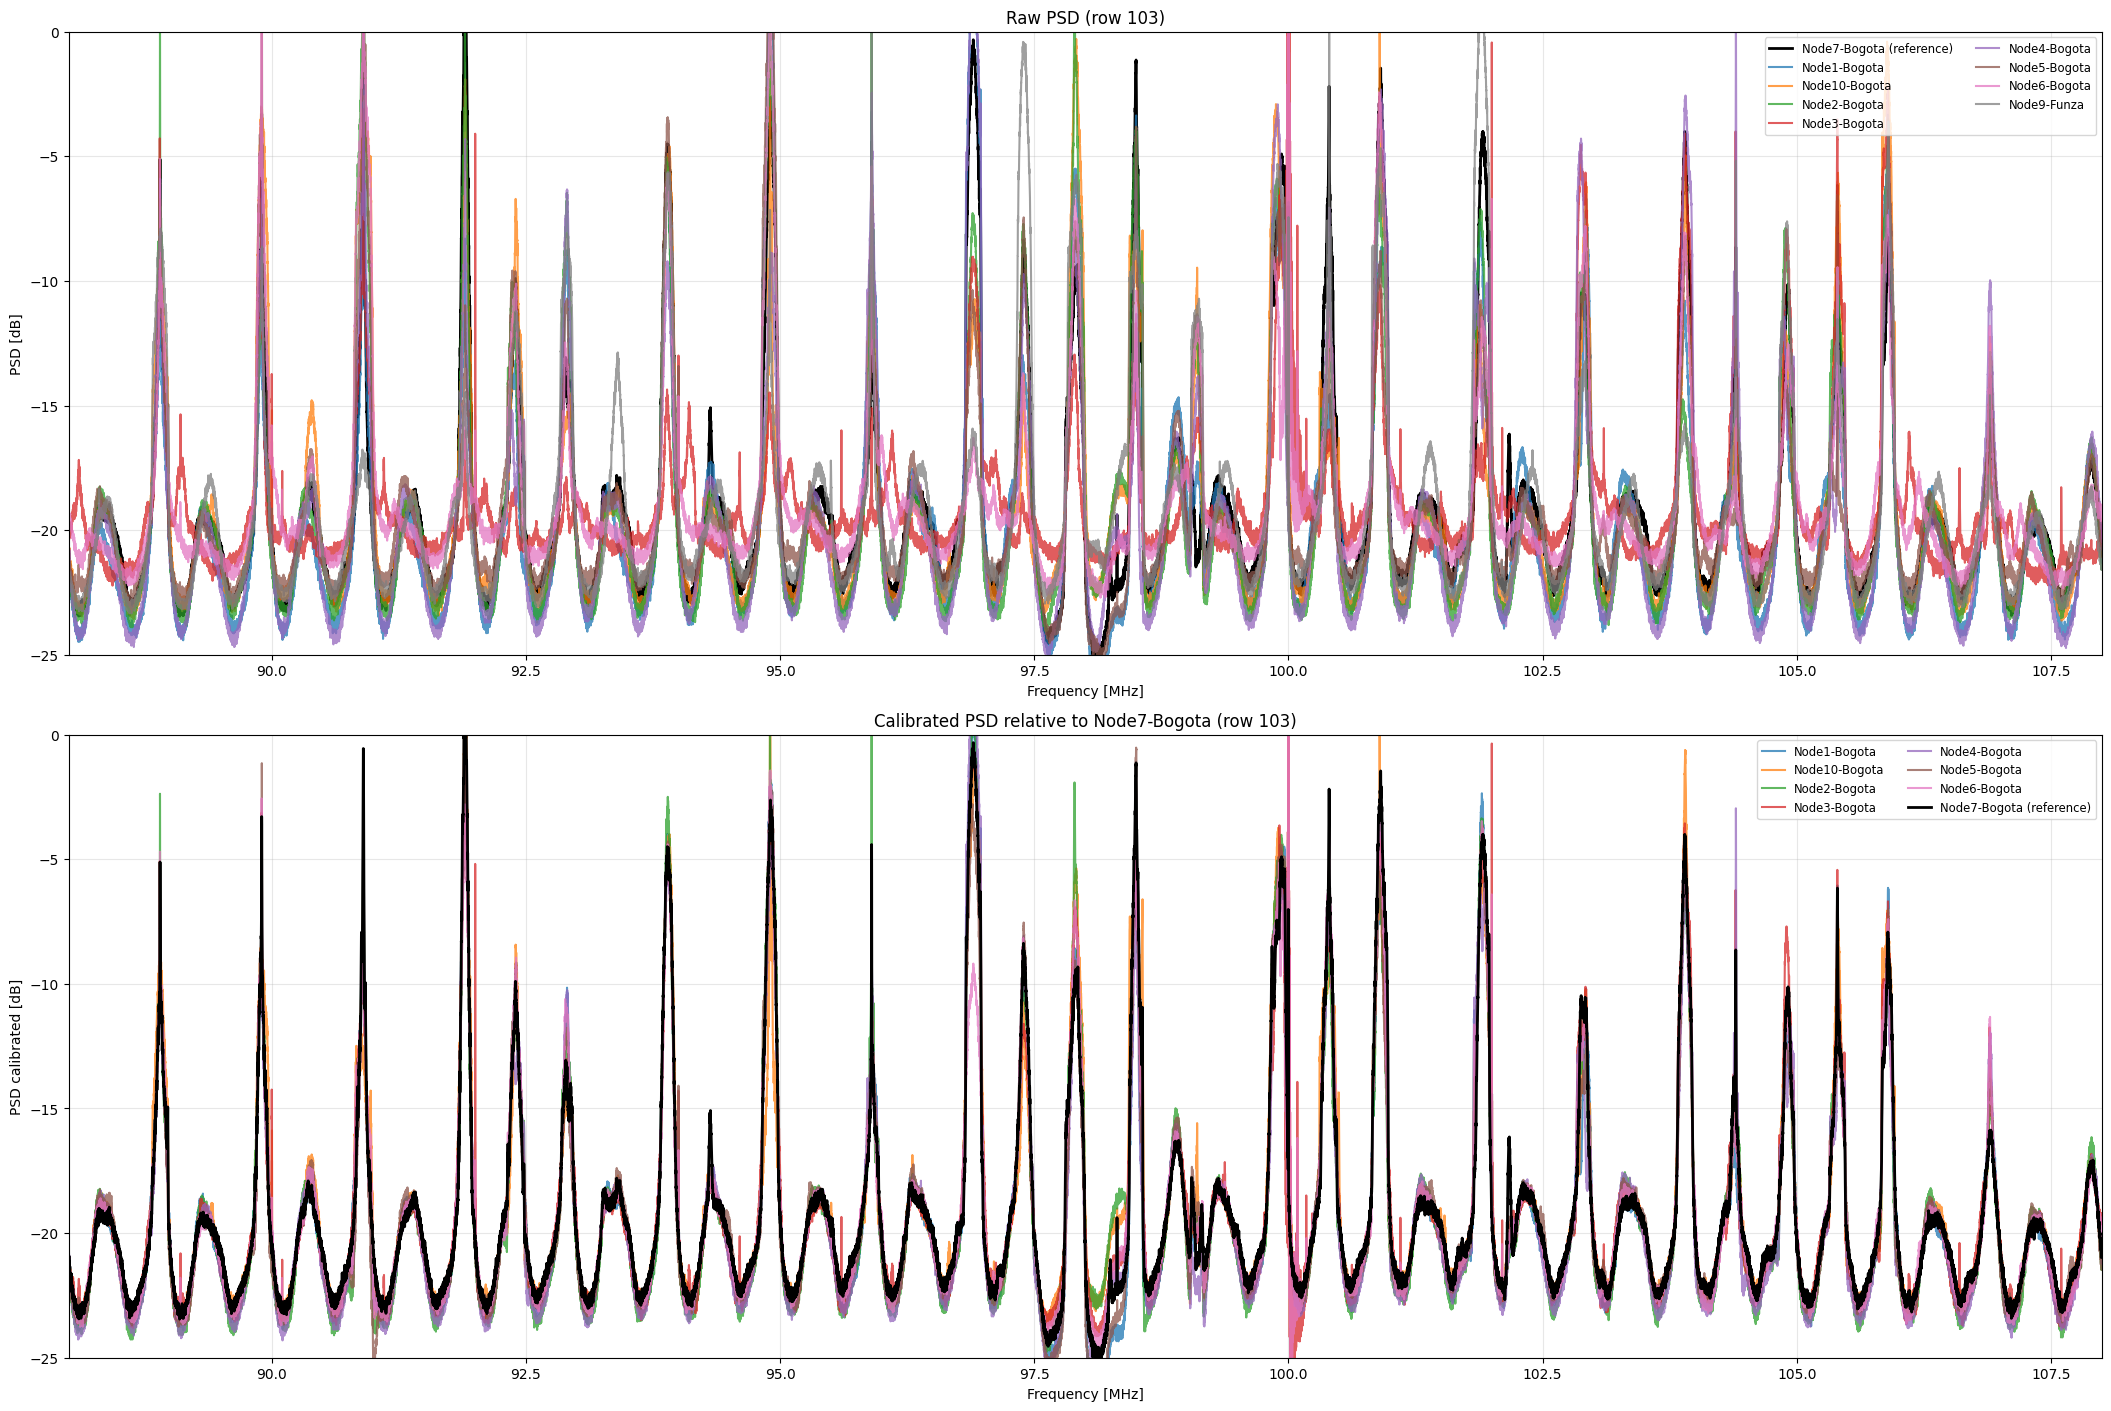

In [4]:
# Full-band PSD comparison over the complete FM sweep [88, 108] MHz
plot_psd_comparison_for_row(
    data_by_node=data_by_node,
    freq_ref_mhz=freq_ref_mhz,
    transfer_db_by_node=transfer_db_by_node,
    row_plot=ROW_PLOT,
    reference_node=REFERENCE_NODE,
    roi_mhz=(88.0, 108.0),
)
